In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, PowerTransformer, FunctionTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [2]:
X = pd.read_parquet("puzzles_features.parquet")
X.head()

,Rating,RatingDeviation,Popularity,NbPlays,num_moves,num_openings,num_themes,has_mate,total_material,material_balance,...,masterVsMaster,hookMate,castling,doubleBishopMate,short,crushing,equality,kingsideAttack,sacrifice,backRankMate
0,1344,76,90,1728,4,2,5,False,7000,0,...,0,0,0,0,1,1,0,0,0,0
1,1526,76,96,22662,6,0,5,False,1400,0,...,0,0,0,0,0,1,0,0,0,0
2,2213,75,97,1240,6,0,5,False,1100,100,...,0,0,0,0,0,1,0,0,0,0
3,1055,81,85,196,4,0,4,False,2200,0,...,0,0,0,0,1,0,0,0,0,0
4,962,91,83,86,4,0,6,False,4200,0,...,0,0,0,0,1,1,0,0,0,0


In [3]:
y = X["Popularity"]

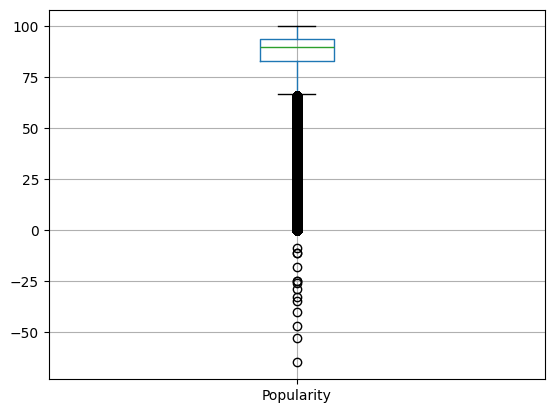

In [4]:
X.boxplot(column="Popularity")
plt.show()

In [5]:
X = X.drop(["Popularity"], axis=1)
X["has_mate"] = X["has_mate"].astype(int)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 800000, Test size: 200000


In [7]:
# Define column groups
log_cols = ["NbPlays"]

scale_cols = ["Rating", "RatingDeviation", "num_moves", "num_themes",
              "total_material", "material_balance", "legal_move_count",
              "white_hanging", "black_hanging", "num_openings"]

binary_cols = [col for col in X_train.columns 
               if col not in log_cols + scale_cols]

print(f"Log+scale: {log_cols}")
print(f"Scale only: {scale_cols}")
print(f"Binary (untouched): {len(binary_cols)} columns")

log_transformer = Pipeline([
    ("log", FunctionTransformer(np.log1p)),
    ("scale", RobustScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("log_scale", log_transformer, log_cols),
    ("scale", RobustScaler(), scale_cols),
    ("passthrough", "passthrough", binary_cols),
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# ── Verify overall ────────────────────────────────────────────────────────────
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_train_scaled min:  ", X_train_scaled.min())
print("X_train_scaled max:  ", X_train_scaled.max())
print("X_test_scaled min:   ", X_test_scaled.min())
print("X_test_scaled max:   ", X_test_scaled.max())

# ── Verify by column group (using index ranges) ───────────────────────────────
n_log   = len(log_cols)
n_scale = len(scale_cols)
n_bin   = len(binary_cols)

log_block    = X_train_scaled[:, :n_log]
scale_block  = X_train_scaled[:, n_log:n_log + n_scale]
binary_block = X_train_scaled[:, n_log + n_scale:]

print(f"\nLog+scaled cols  ({n_log} cols):    min={log_block.min():.2f},    max={log_block.max():.2f}")
print(f"Scaled cols      ({n_scale} cols):   min={scale_block.min():.2f},   max={scale_block.max():.2f}")
print(f"Binary cols      ({n_bin} cols):     min={binary_block.min():.2f},  max={binary_block.max():.2f}")

# ── Check for NaNs ────────────────────────────────────────────────────────────
print(f"\nNaNs in X_train_scaled: {np.isnan(X_train_scaled).sum()}")
print(f"NaNs in X_test_scaled:  {np.isnan(X_test_scaled).sum()}")

Log+scale: ['NbPlays']
Scale only: ['Rating', 'RatingDeviation', 'num_moves', 'num_themes', 'total_material', 'material_balance', 'legal_move_count', 'white_hanging', 'black_hanging', 'num_openings']
Binary (untouched): 78 columns
X_train_scaled shape: (800000, 89)
X_train_scaled min:   -3.0
X_train_scaled max:   35.083333333333336
X_test_scaled min:    -3.0
X_test_scaled max:    35.083333333333336

Log+scaled cols  (1 cols):    min=-2.45,    max=2.69
Scaled cols      (10 cols):   min=-3.00,   max=35.08
Binary cols      (78 cols):     min=0.00,  max=1.00

NaNs in X_train_scaled: 0
NaNs in X_test_scaled:  0


In [8]:
pt = PowerTransformer(method="yeo-johnson")
y_train_t = pt.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_t  = pt.transform(y_test.values.reshape(-1, 1)).ravel()

print("y_train_t min:", y_train_t.min())
print("y_train_t max:", y_train_t.max())
print("y_train_t mean:", y_train_t.mean())
print("y_train_t std:", y_train_t.std())


y_train_t min: -2.5469074765461928
y_train_t max: 1.5861207501846257
y_train_t mean: -2.5281110538344365e-16
y_train_t std: 1.0


In [9]:
# Train
model = LinearRegression()
model.fit(X_train_scaled, y_train_t)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
y_pred_t = model.predict(X_test_scaled)

print("1. NaNs in y_pred_t (raw):        ", np.isnan(y_pred_t).sum())

y_pred_t_clipped = np.clip(y_pred_t, -2.5, 5)
print("2. NaNs in y_pred_t_clipped:      ", np.isnan(y_pred_t_clipped).sum())

y_pred = pt.inverse_transform(y_pred_t_clipped.reshape(-1, 1)).ravel()
print("3. NaNs after inverse_transform:  ", np.isnan(y_pred).sum())

y_pred = np.clip(y_pred, -100, 100)
print("4. NaNs after final clip:         ", np.isnan(y_pred).sum())

1. NaNs in y_pred_t (raw):         0
2. NaNs in y_pred_t_clipped:       0
3. NaNs after inverse_transform:   0
4. NaNs after final clip:          0


In [11]:
print(f"\nNaNs in y_test: {np.isnan(y_test).sum()}")
print(f"NaNs in y_pred:  {np.isnan(y_pred).sum()}")


NaNs in y_test: 0
NaNs in y_pred:  0


In [12]:
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 12.0514
MAE  : 6.8549
R²   : 0.2816


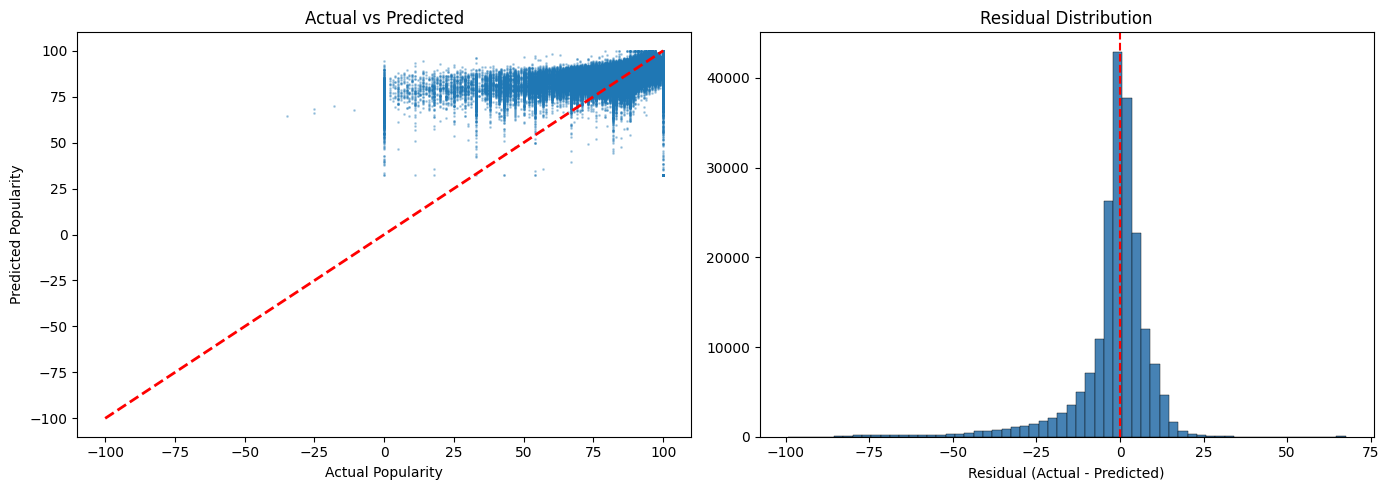

In [13]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, s=1)
axes[0].plot([-100, 100], [-100, 100], "r--", lw=2)
axes[0].set_xlabel("Actual Popularity")
axes[0].set_ylabel("Predicted Popularity")
axes[0].set_title("Actual vs Predicted")

# Residuals distribution
axes[1].hist(residuals, bins=60, color="steelblue", edgecolor="k", linewidth=0.3)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()